In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm


# Configuration

## Config of Model Training

In [8]:
EPOCHS = 100
# BATCH_SIZE = 128
LR = 0.05
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
torch.manual_seed(SEED)
print(f"Using device: {DEVICE}")


Using device: cuda


# Data Loading for CIFAR-100 for training and validation sets

## Loading and splitting

In [9]:
# Data Loaders
cifar100_mean, cifar100_std = (0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)

# Training transform (with augmentation)
TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std),
])

# Validation / eval transform — deterministic, no augmentation
VAL_TRANSFORM = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std),
])

# Keep DATA_TRANSFORM as alias so downstream code still works
DATA_TRANSFORM = TRAIN_TRANSFORM

# Load both datasets with the correct transforms
train_full = datasets.CIFAR100(root='./data', train=True, download=True, transform=TRAIN_TRANSFORM)
val_full   = datasets.CIFAR100(root='./data', train=True, download=True, transform=VAL_TRANSFORM)

train_split = int(0.8 * len(train_full))
val_split   = len(train_full) - train_split

# Deterministic 80/20 split — same indices for both datasets
gen = torch.Generator().manual_seed(SEED)
train_indices, val_indices = torch.utils.data.random_split(
    range(len(train_full)), [train_split, val_split], generator=gen
)

train_data = torch.utils.data.Subset(train_full, list(train_indices))
val_data   = torch.utils.data.Subset(val_full,   list(val_indices))

train_loader = DataLoader(train_data, batch_size=256, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_data,   batch_size=512, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)


# Baseline Model

In [10]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False) # adapt for 32x32 format of CIFAR100
model.maxpool = nn.Identity()
model.fc = nn.Linear(model.fc.in_features, 100)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Training Metrics and Utilities

In [11]:
@torch.no_grad()
def accuracy(logits: torch.Tensor, y: torch.Tensor) -> float:
    """Compute classification accuracy from logits."""
    return (logits.argmax(1) == y).float().mean().item()

scaler = torch.amp.GradScaler(DEVICE)
def train_one_epoch(model: nn.Module, loader: DataLoader, criterion, optimizer) -> tuple[float, float]:
    """Standard training loop for one epoch."""
    model.train()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    for x, y in loader:                      # x: [B, C, H, W]
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast(DEVICE):
          logits = model(x)                    # [B, 10]
          loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        bs = x.size(0)
        tot += bs
        tot_loss   += loss.item() * bs
        tot_correct+= (logits.argmax(1) == y).sum().item()
    return tot_loss / tot, tot_correct / tot


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion) -> tuple[float, float]:
    """Evaluation loop."""
    model.eval()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        bs = x.size(0)
        tot += bs
        tot_loss   += loss.item() * bs
        tot_correct+= (logits.argmax(1) == y).sum().item()
    return tot_loss / tot, tot_correct / tot

@torch.no_grad()
def evaluate_modified(model, loader, criterion, coarse_groups=None, topk=(1, 5)):
    model.eval()
    tot_loss = 0.0
    correct = {k: 0 for k in topk}
    coarse_correct = tot = 0
    fine_to_coarse = None
    if coarse_groups is not None:
        fine_to_coarse = make_fine_to_coarse(coarse_groups).to(DEVICE)
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        if isinstance(out, tuple):
            final_probs, coarse_probs = out[0], out[1]
            loss_out = criterion(final_probs, coarse_probs, y)
            logits = final_probs
        else:
            loss_out = criterion(out, y)
            logits = out
        loss = loss_out[0] if isinstance(loss_out, tuple) else loss_out
        maxk = max(topk)
        topk_preds = logits.topk(maxk, dim=1).indices  # (B, maxk)
        for k in topk:
            correct[k] += (topk_preds[:, :k] == y.unsqueeze(1)).any(dim=1).sum().item()
        if fine_to_coarse is not None:
            pred_coarse = fine_to_coarse[topk_preds[:, 0]]
            true_coarse = fine_to_coarse[y]
            coarse_correct += (pred_coarse == true_coarse).sum().item()
        bs = x.size(0)
        tot += bs
        tot_loss += loss.item() * bs
    result = {
        "loss": tot_loss / tot,
        "top1_acc": correct[1] / tot,
        "top5_acc": correct[5] / tot,
    }
    if fine_to_coarse is not None:
        result["coarse_acc"] = coarse_correct / tot
    return result

def plot_history(history: dict, title: str):
    """Plot training history."""
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'],   label='Val Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history['train_accs'], label='Train Acc')
    plt.plot(history['val_accs'],   label='Val Acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy'); plt.legend()
    plt.suptitle(title)
    plt.tight_layout(); plt.show()


@torch.no_grad()
def show_errors(model: nn.Module, loader: DataLoader, n: int = 6):
    """Display misclassified examples."""
    model.eval(); shown = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        preds = logits.argmax(1)
        wrong = torch.where(preds != y)[0]
        for i in wrong[:n]:
            # Check if the image is 1-channel or 3-channel
            img_data = x[i].cpu().squeeze()
            if img_data.ndim == 2: # Grayscale image
                plt.imshow(img_data, cmap='gray')
            else: # Color image (e.g., from transfer learning transform)
                # Permute dimensions from (C, H, W) to (H, W, C) for matplotlib
                plt.imshow(img_data.permute(1, 2, 0))

            # plt.title(f"True: {CLASSES[y[i].item()]} | Pred: {CLASSES[preds[i].item()]}")
            plt.axis('off'); plt.show(); shown += 1
        if shown >= n: break

def count_params(model: nn.Module) -> str:
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return f"{n/1e6:.2f}M"

# Training Run

In [12]:
history = {"train_loss": [], "val_loss": [], "train_accs": [], "val_accs": []}
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accs"].append(train_acc)
    history["val_accs"].append(val_acc)
    print(f"  Epoch {epoch+1}/{EPOCHS} | Train: {train_acc:.3f} | Val: {val_acc:.3f}")


torch.save(model.state_dict(), "resnet18_cifar100.pth")
print("\nDone. Model saved to resnet18_cifar100.pth")

  Epoch 1/100 | Train: 0.301 | Val: 0.414
  Epoch 2/100 | Train: 0.538 | Val: 0.506
  Epoch 3/100 | Train: 0.623 | Val: 0.567
  Epoch 4/100 | Train: 0.670 | Val: 0.567
  Epoch 5/100 | Train: 0.710 | Val: 0.618
  Epoch 6/100 | Train: 0.736 | Val: 0.597
  Epoch 7/100 | Train: 0.766 | Val: 0.648
  Epoch 8/100 | Train: 0.784 | Val: 0.619
  Epoch 9/100 | Train: 0.801 | Val: 0.635
  Epoch 10/100 | Train: 0.820 | Val: 0.663
  Epoch 11/100 | Train: 0.834 | Val: 0.670
  Epoch 12/100 | Train: 0.845 | Val: 0.646
  Epoch 13/100 | Train: 0.859 | Val: 0.662
  Epoch 14/100 | Train: 0.868 | Val: 0.648
  Epoch 15/100 | Train: 0.876 | Val: 0.682
  Epoch 16/100 | Train: 0.886 | Val: 0.666
  Epoch 17/100 | Train: 0.891 | Val: 0.669
  Epoch 18/100 | Train: 0.901 | Val: 0.673
  Epoch 19/100 | Train: 0.904 | Val: 0.663
  Epoch 20/100 | Train: 0.911 | Val: 0.678
  Epoch 21/100 | Train: 0.919 | Val: 0.671
  Epoch 22/100 | Train: 0.922 | Val: 0.694
  Epoch 23/100 | Train: 0.927 | Val: 0.685
  Epoch 24/100 | Tra

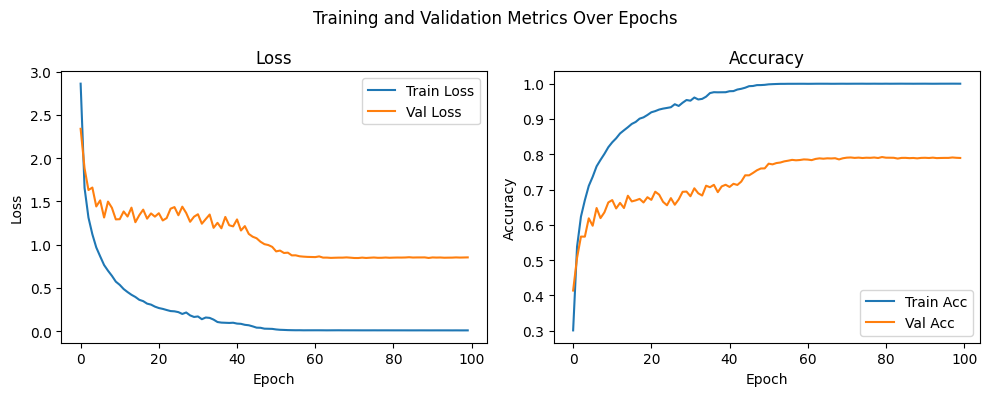

In [13]:
plot_history(history, "Training and Validation Metrics Over Epochs")

## Ablation Studies


In [14]:
import copy
import itertools
import os
import time
from typing import Dict, List, Tuple
from torch.utils.tensorboard import SummaryWriter
LOG_DIR = "runs"

Data helper

In [15]:
def get_augmentation_transform(strategy) -> transforms.Compose:
    normalize = transforms.Normalize(cifar100_mean, cifar100_std)

    if strategy == "none":
        return transforms.Compose([transforms.ToTensor(), normalize])

    elif strategy == "standard":
        return transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            normalize,
        ])

    elif strategy == "strong":
        return transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.4, contrast=0.4,
                                   saturation=0.4, hue=0.1),
            transforms.ToTensor(),
            normalize,
            transforms.RandomErasing(p=0.5, scale=(0.02, 0.2)),
        ])

    elif strategy == "cutout":
        return transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            normalize,
            transforms.RandomErasing(p=1.0, scale=(0.0625, 0.25),
                                     ratio=(1.0, 1.0)),
        ])

    else:
        raise ValueError(f"Unknown augmentation strategy: {strategy!r}")


def build_loaders(aug_strategy: str = "standard",
                  batch_size: int = 128) -> Tuple[DataLoader, DataLoader]:
    # FIX: load train and val with their own correct transforms.
    # Previously, random_split was applied to outer-scope full_data,
    # ignoring both aug_strategy and the batch_size parameter.
    train_ds = datasets.CIFAR100(root="./data", train=True, download=True,
                                 transform=get_augmentation_transform(aug_strategy))
    val_ds   = datasets.CIFAR100(root="./data", train=True, download=True,
                                 transform=VAL_TRANSFORM)  # always clean for val

    n_total     = len(train_ds)
    n_train     = int(0.8 * n_total)
    n_val       = n_total - n_train

    gen = torch.Generator().manual_seed(SEED)
    train_idx, val_idx = torch.utils.data.random_split(
        range(n_total), [n_train, n_val], generator=gen
    )

    train_subset = torch.utils.data.Subset(train_ds, list(train_idx))
    val_subset   = torch.utils.data.Subset(val_ds,   list(val_idx))

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=True, persistent_workers=True)
    val_loader   = DataLoader(val_subset,   batch_size=batch_size * 2, shuffle=False,
                              num_workers=4, pin_memory=True, persistent_workers=True)

    return train_loader, val_loader


def base_resenet() -> nn.Module:
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 100)
    return model


Architectural Variants

In [16]:
def build_arch_variant(variant: str) -> nn.Module:

    if variant == "resnet18_baseline":
        return base_resenet()

    elif variant == "resnet18_no_pretrain":
        m = models.resnet18(weights=None)
        m.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        m.maxpool = nn.Identity()
        m.fc = nn.Linear(m.fc.in_features, 100)
        return m

    elif variant == "resnet34":
        m = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        m.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        m.maxpool = nn.Identity()
        m.fc = nn.Linear(m.fc.in_features, 100)
        return m

    elif variant == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        m.maxpool = nn.Identity()
        m.fc = nn.Linear(m.fc.in_features, 100)
        return m

    elif variant == "shallow_resnet":
        m = base_resenet()
        m.layer4 = nn.Identity()
        m.fc = nn.Linear(256, 100)
        return m

ARCH_VARIANTS = [
    "resnet18_baseline",
    "resnet18_no_pretrain",
    "resnet34",
    "resnet50",
    "shallow_resnet",
]

# Regularization Variants

In [17]:
class ResNet18WithDropout(nn.Module):
    def __init__(self, dropout_p: float = 0.5):
        super().__init__()
        base = base_resenet()

        self.backbone = nn.Sequential(
            base.conv1, base.bn1, base.relu,
            base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4,
            base.avgpool,
        )
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc = nn.Linear(512, 100)

    def forward(self, x):
        x = self.backbone(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)


REGULARIZATION_CONFIGS: List[Dict] = [
 #   {"name": "no_reg",          "wd": 0.0,    "dropout": 0.0,  "aug": "none"},
 #   {"name": "wd_only",         "wd": 5e-4,   "dropout": 0.0,  "aug": "none"},
 #   {"name": "aug_only",        "wd": 0.0,    "dropout": 0.0,  "aug": "standard"},
 #   {"name": "dropout_only",    "wd": 0.0,    "dropout": 0.5,  "aug": "none"},
    {"name": "wd_aug",          "wd": 5e-4,   "dropout": 0.0,  "aug": "standard"},
 #  {"name": "wd_dropout",      "wd": 5e-4,   "dropout": 0.5,  "aug": "none"},
    {"name": "aug_dropout",     "wd": 0.0,    "dropout": 0.5,  "aug": "strong"},
 #   {"name": "all_reg",         "wd": 5e-4,   "dropout": 0.5,  "aug": "strong"},
    {"name": "strong_aug_only", "wd": 0.0,    "dropout": 0.0,  "aug": "strong"},
    {"name": "cutout_aug",      "wd": 5e-4,   "dropout": 0.0,  "aug": "cutout"},
]

TTA Variants

In [18]:
TTA_TRANSFORMS = [
    transforms.Compose([transforms.ToTensor(),
                        transforms.Normalize(cifar100_mean, cifar100_std)]),
    transforms.Compose([transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(),
                        transforms.Normalize(cifar100_mean, cifar100_std)]),
    transforms.Compose([transforms.RandomCrop(32, padding=4),
                        transforms.ToTensor(),
                        transforms.Normalize(cifar100_mean, cifar100_std)]),
    transforms.Compose([transforms.RandomCrop(32, padding=4),
                        transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(),
                        transforms.Normalize(cifar100_mean, cifar100_std)]),
    transforms.Compose([transforms.ColorJitter(brightness=0.2, contrast=0.2),
                        transforms.ToTensor(),
                        transforms.Normalize(cifar100_mean, cifar100_std)]),
]

@torch.no_grad()
def tta_evaluate(
    model: nn.Module,
    val_dataset,
    indices: List[int],
    device: torch.device,
    strategy: str = "prob_avg",
    n_augments: int = 5,
) -> float:

    model.eval()
    correct, total = 0, 0
    tta_tfms = TTA_TRANSFORMS[:n_augments]

    for idx in indices:
        raw_img, label = val_dataset[idx]

        if strategy == "single":
            img = DATA_TRANSFORM(raw_img).unsqueeze(0).to(device)
            pred = model(img).argmax(1).item()

        elif strategy in ("prob_avg", "logit_avg"):
            preds = []
            for tfm in tta_tfms:
                img = tfm(raw_img).unsqueeze(0).to(device)
                out = model(img)
                preds.append(torch.softmax(out, 1) if strategy == "prob_avg" else out)
            pred = torch.stack(preds, 0).mean(0).argmax(1).item()

        elif strategy == "majority":
            votes = []
            for tfm in tta_tfms:
                img = tfm(raw_img).unsqueeze(0).to(device)
                votes.append(model(img).argmax(1).item())
            pred = max(set(votes), key=votes.count)

        else:
            raise ValueError(f"Unknown TTA strategy: {strategy!r}")

        correct += int(pred == label)
        total += 1

    return correct / total

In [19]:
def run_experiment(
    exp_name: str,
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    weight_decay: float = 5e-4,
    epochs: int = EPOCHS,
    device: torch.device = DEVICE,
) -> Dict:

    writer = SummaryWriter(log_dir=os.path.join(LOG_DIR, exp_name))
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    best_state = None
    history = {
        "train_loss": [], "val_loss": [],
        "train_accs": [], "val_accs": [],
        "val_top5":   [], "val_coarse": [],  # val_coarse populated below
    }
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val = evaluate_modified(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val["loss"])
        history["train_accs"].append(train_acc)
        history["val_accs"].append(val["top1_acc"])
        history["val_top5"].append(val["top5_acc"])
        # FIX: val_coarse was tracked in history but never appended.
        # evaluate_modified returns coarse_acc only when coarse_groups is
        # passed; for standard models it's absent, so default to None.
        history["val_coarse"].append(val.get("coarse_acc", None))

        print(f"  Epoch {epoch+1}/{epochs} | Train: {train_acc:.3f} | "
              f"Val Top-1: {val['top1_acc']:.3f} | Val Top-5: {val['top5_acc']:.3f}")

        writer.add_scalars("Loss",     {"train": train_loss, "val": val["loss"]}, epoch)
        writer.add_scalars("Accuracy", {"train": train_acc,  "val": val["top1_acc"]}, epoch)
        writer.add_scalar("Accuracy/top5", val["top5_acc"], epoch)
        writer.add_scalar("LR", scheduler.get_last_lr()[0], epoch)

        if val["top1_acc"] > best_val_acc:
            best_val_acc = val["top1_acc"]
            best_state = copy.deepcopy(model.state_dict())

    params = count_params(model)
    writer.close()
    return {
        "exp_name":     exp_name,
        "best_val_acc": best_val_acc,
        "history":      history,
        "best_state":   best_state,
        "params":       params,
    }


Runners

In [20]:
def run_architecture_ablations(epochs: int = EPOCHS) -> List[Dict]:

    train_loader, val_loader = build_loaders("standard")
    results = []
    for variant in ARCH_VARIANTS:
        print(f"\n{'='*60}\n  ARCH ABLATION: {variant}\n{'='*60}")
        model = build_arch_variant(variant)
        res = run_experiment(
            exp_name = f"arch/{variant}",
            model = model,
            train_loader= train_loader,
            val_loader = val_loader,
            weight_decay= 5e-4,
            epochs = epochs,
        )
        results.append(res)
    return results


def run_regularization_ablations(epochs: int = EPOCHS) -> List[Dict]:

    results = []
    for cfg in REGULARIZATION_CONFIGS:
        name = cfg["name"]
        wd = cfg["wd"]
        dropout = cfg["dropout"]
        aug = cfg["aug"]

        print(f"\n{'='*60}\n  REG ABLATION: {name}\n{'='*60}")

        train_loader, val_loader = build_loaders(aug)
        model = (ResNet18WithDropout(dropout_p=dropout)
                 if dropout > 0.0 else base_resenet())

        res = run_experiment(
            exp_name = f"reg/{name}",
            model = model,
            train_loader = train_loader,
            val_loader = val_loader,
            weight_decay = wd,
            epochs = epochs,
        )
        res["config"] = cfg
        results.append(res)
    return results



def run_tta_ablations(
    trained_model: nn.Module,
    n_eval_samples: int = 2000,
) -> Dict[str, float]:

    raw_dataset = datasets.CIFAR100(root="./data", train=True, download=True,
                                    transform=None)
    n_train = int(0.8 * len(raw_dataset))
    gen = torch.Generator().manual_seed(SEED)
    _, val_idx = torch.utils.data.random_split(
        range(len(raw_dataset)), [n_train, len(raw_dataset) - n_train], generator=gen
    )
    val_indices = list(val_idx)[:n_eval_samples]

    writer = SummaryWriter(log_dir=os.path.join(LOG_DIR, "tta"))
    tta_strats = ["single", "prob_avg", "logit_avg", "majority"]
    tta_results = {}

    for n_aug in [1, 3, 5]:
        for strat in tta_strats:
            if strat == "single" and n_aug > 1:
                continue

            key = f"{strat}_n{n_aug}" if strat != "single" else "single_view"
            print(f"  TTA: strategy={strat!r}  n_aug={n_aug}  ...", end=" ", flush=True)
            acc = tta_evaluate(trained_model, raw_dataset, val_indices,
                               DEVICE, strategy=strat, n_augments=n_aug)
            tta_results[key] = acc
            writer.add_scalar("TTA_Accuracy", acc,
                               global_step=tta_strats.index(strat) * 3 + n_aug)
            print(f"acc={acc:.4f}")

    writer.close()
    return tta_results

def print_results_table(results: List[Dict], title: str):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(f"  {'Experiment':<35} {'Best Val Acc':>12}")
    print(f"  {'-'*35} {'-'*12}")
    sorted_res = sorted(results, key=lambda r: r["best_val_acc"], reverse=True)
    for r in sorted_res:
        print(f"  {r['exp_name']:<35} {r['best_val_acc']:>12.4f}")
    print()


def print_tta_table(tta_results: Dict[str, float]):
    print(f"\n{'='*60}")
    print("  Inference-Time Aggregation Results")
    print(f"{'='*60}")
    print(f"  {'Strategy':<30} {'Accuracy':>10}")
    print(f"  {'-'*30} {'-'*10}")
    for k, v in sorted(tta_results.items(), key=lambda x: -x[1]):
        print(f"  {k:<30} {v:>10.4f}")
    print()

Results

In [21]:
arch_results = run_architecture_ablations(epochs=EPOCHS)
print_results_table(arch_results, "Architecture Ablations")


  ARCH ABLATION: resnet18_baseline
  Epoch 1/100 | Train: 0.238 | Val Top-1: 0.320 | Val Top-5: 0.638
  Epoch 2/100 | Train: 0.469 | Val Top-1: 0.497 | Val Top-5: 0.815
  Epoch 3/100 | Train: 0.555 | Val Top-1: 0.500 | Val Top-5: 0.823
  Epoch 4/100 | Train: 0.601 | Val Top-1: 0.575 | Val Top-5: 0.859
  Epoch 5/100 | Train: 0.634 | Val Top-1: 0.533 | Val Top-5: 0.839
  Epoch 6/100 | Train: 0.656 | Val Top-1: 0.571 | Val Top-5: 0.857
  Epoch 7/100 | Train: 0.676 | Val Top-1: 0.583 | Val Top-5: 0.862
  Epoch 8/100 | Train: 0.696 | Val Top-1: 0.604 | Val Top-5: 0.878
  Epoch 9/100 | Train: 0.721 | Val Top-1: 0.603 | Val Top-5: 0.875
  Epoch 10/100 | Train: 0.734 | Val Top-1: 0.614 | Val Top-5: 0.888
  Epoch 11/100 | Train: 0.743 | Val Top-1: 0.621 | Val Top-5: 0.886
  Epoch 12/100 | Train: 0.754 | Val Top-1: 0.636 | Val Top-5: 0.891
  Epoch 13/100 | Train: 0.764 | Val Top-1: 0.618 | Val Top-5: 0.879
  Epoch 14/100 | Train: 0.772 | Val Top-1: 0.601 | Val Top-5: 0.867
  Epoch 15/100 | Trai

100%|██████████| 83.3M/83.3M [00:00<00:00, 181MB/s]


  Epoch 1/100 | Train: 0.261 | Val Top-1: 0.201 | Val Top-5: 0.470
  Epoch 2/100 | Train: 0.508 | Val Top-1: 0.504 | Val Top-5: 0.810
  Epoch 3/100 | Train: 0.594 | Val Top-1: 0.508 | Val Top-5: 0.817
  Epoch 4/100 | Train: 0.639 | Val Top-1: 0.579 | Val Top-5: 0.869
  Epoch 5/100 | Train: 0.670 | Val Top-1: 0.593 | Val Top-5: 0.879
  Epoch 6/100 | Train: 0.687 | Val Top-1: 0.590 | Val Top-5: 0.869
  Epoch 7/100 | Train: 0.702 | Val Top-1: 0.595 | Val Top-5: 0.883
  Epoch 8/100 | Train: 0.719 | Val Top-1: 0.625 | Val Top-5: 0.886
  Epoch 9/100 | Train: 0.732 | Val Top-1: 0.618 | Val Top-5: 0.884
  Epoch 10/100 | Train: 0.748 | Val Top-1: 0.625 | Val Top-5: 0.887
  Epoch 11/100 | Train: 0.758 | Val Top-1: 0.617 | Val Top-5: 0.880
  Epoch 12/100 | Train: 0.770 | Val Top-1: 0.612 | Val Top-5: 0.877
  Epoch 13/100 | Train: 0.780 | Val Top-1: 0.628 | Val Top-5: 0.884
  Epoch 14/100 | Train: 0.787 | Val Top-1: 0.610 | Val Top-5: 0.873
  Epoch 15/100 | Train: 0.790 | Val Top-1: 0.662 | Val To

100%|██████████| 97.8M/97.8M [00:00<00:00, 305MB/s]


  Epoch 1/100 | Train: 0.369 | Val Top-1: 0.576 | Val Top-5: 0.862
  Epoch 2/100 | Train: 0.661 | Val Top-1: 0.650 | Val Top-5: 0.910
  Epoch 3/100 | Train: 0.732 | Val Top-1: 0.692 | Val Top-5: 0.926
  Epoch 4/100 | Train: 0.774 | Val Top-1: 0.691 | Val Top-5: 0.926
  Epoch 5/100 | Train: 0.801 | Val Top-1: 0.715 | Val Top-5: 0.935
  Epoch 6/100 | Train: 0.817 | Val Top-1: 0.714 | Val Top-5: 0.938
  Epoch 7/100 | Train: 0.826 | Val Top-1: 0.701 | Val Top-5: 0.929
  Epoch 8/100 | Train: 0.835 | Val Top-1: 0.708 | Val Top-5: 0.932
  Epoch 9/100 | Train: 0.841 | Val Top-1: 0.715 | Val Top-5: 0.933
  Epoch 10/100 | Train: 0.851 | Val Top-1: 0.699 | Val Top-5: 0.925
  Epoch 11/100 | Train: 0.851 | Val Top-1: 0.700 | Val Top-5: 0.925
  Epoch 12/100 | Train: 0.858 | Val Top-1: 0.718 | Val Top-5: 0.933
  Epoch 13/100 | Train: 0.860 | Val Top-1: 0.690 | Val Top-5: 0.924
  Epoch 14/100 | Train: 0.866 | Val Top-1: 0.704 | Val Top-5: 0.932
  Epoch 15/100 | Train: 0.863 | Val Top-1: 0.701 | Val To

In [22]:
reg_results = run_regularization_ablations(epochs=EPOCHS)
print_results_table(reg_results, "Regularisation Ablations")


  REG ABLATION: wd_aug
  Epoch 1/100 | Train: 0.250 | Val Top-1: 0.297 | Val Top-5: 0.596
  Epoch 2/100 | Train: 0.464 | Val Top-1: 0.461 | Val Top-5: 0.779
  Epoch 3/100 | Train: 0.552 | Val Top-1: 0.513 | Val Top-5: 0.820
  Epoch 4/100 | Train: 0.600 | Val Top-1: 0.514 | Val Top-5: 0.823
  Epoch 5/100 | Train: 0.631 | Val Top-1: 0.535 | Val Top-5: 0.833
  Epoch 6/100 | Train: 0.655 | Val Top-1: 0.572 | Val Top-5: 0.854
  Epoch 7/100 | Train: 0.673 | Val Top-1: 0.577 | Val Top-5: 0.867
  Epoch 8/100 | Train: 0.698 | Val Top-1: 0.596 | Val Top-5: 0.875
  Epoch 9/100 | Train: 0.717 | Val Top-1: 0.595 | Val Top-5: 0.870
  Epoch 10/100 | Train: 0.729 | Val Top-1: 0.597 | Val Top-5: 0.871
  Epoch 11/100 | Train: 0.745 | Val Top-1: 0.625 | Val Top-5: 0.886
  Epoch 12/100 | Train: 0.752 | Val Top-1: 0.600 | Val Top-5: 0.869
  Epoch 13/100 | Train: 0.760 | Val Top-1: 0.607 | Val Top-5: 0.867
  Epoch 14/100 | Train: 0.772 | Val Top-1: 0.620 | Val Top-5: 0.881
  Epoch 15/100 | Train: 0.777 | V

In [23]:
reg_results = run_regularization_ablations(epochs=EPOCHS)
print_results_table(reg_results, "Regularisation Ablations")


  REG ABLATION: wd_aug
  Epoch 1/100 | Train: 0.243 | Val Top-1: 0.406 | Val Top-5: 0.736
  Epoch 2/100 | Train: 0.476 | Val Top-1: 0.503 | Val Top-5: 0.815
  Epoch 3/100 | Train: 0.560 | Val Top-1: 0.533 | Val Top-5: 0.840
  Epoch 4/100 | Train: 0.605 | Val Top-1: 0.544 | Val Top-5: 0.847
  Epoch 5/100 | Train: 0.640 | Val Top-1: 0.563 | Val Top-5: 0.851
  Epoch 6/100 | Train: 0.662 | Val Top-1: 0.604 | Val Top-5: 0.876
  Epoch 7/100 | Train: 0.680 | Val Top-1: 0.596 | Val Top-5: 0.881
  Epoch 8/100 | Train: 0.705 | Val Top-1: 0.597 | Val Top-5: 0.868
  Epoch 9/100 | Train: 0.724 | Val Top-1: 0.587 | Val Top-5: 0.864
  Epoch 10/100 | Train: 0.736 | Val Top-1: 0.586 | Val Top-5: 0.853
  Epoch 11/100 | Train: 0.750 | Val Top-1: 0.613 | Val Top-5: 0.878
  Epoch 12/100 | Train: 0.759 | Val Top-1: 0.609 | Val Top-5: 0.879
  Epoch 13/100 | Train: 0.763 | Val Top-1: 0.638 | Val Top-5: 0.892
  Epoch 14/100 | Train: 0.776 | Val Top-1: 0.637 | Val Top-5: 0.890
  Epoch 15/100 | Train: 0.786 | V

In [24]:
best = max(arch_results, key=lambda r: r["best_val_acc"])
print(f"\nUsing best arch model: {best['exp_name']} "
      f"(val_acc={best['best_val_acc']:.4f})")


Using best arch model: arch/resnet50 (val_acc=0.8220)


In [25]:
tta_model = build_arch_variant(
    best["exp_name"].replace("arch/", ""))
tta_model.load_state_dict(best["best_state"])
tta_model = tta_model.to(DEVICE)
tta_results = run_tta_ablations(tta_model, n_eval_samples=2000)
print_tta_table(tta_results)

  TTA: strategy='single'  n_aug=1  ... acc=0.8175
  TTA: strategy='prob_avg'  n_aug=1  ... acc=0.8285
  TTA: strategy='logit_avg'  n_aug=1  ... acc=0.8285
  TTA: strategy='majority'  n_aug=1  ... acc=0.8285
  TTA: strategy='prob_avg'  n_aug=3  ... acc=0.8400
  TTA: strategy='logit_avg'  n_aug=3  ... acc=0.8365
  TTA: strategy='majority'  n_aug=3  ... acc=0.8345
  TTA: strategy='prob_avg'  n_aug=5  ... acc=0.8380
  TTA: strategy='logit_avg'  n_aug=5  ... acc=0.8390
  TTA: strategy='majority'  n_aug=5  ... acc=0.8365

  Inference-Time Aggregation Results
  Strategy                         Accuracy
  ------------------------------ ----------
  prob_avg_n3                        0.8400
  logit_avg_n5                       0.8390
  prob_avg_n5                        0.8380
  logit_avg_n3                       0.8365
  majority_n5                        0.8365
  majority_n3                        0.8345
  prob_avg_n1                        0.8285
  logit_avg_n1                       0.8285
 

# HD-CNN Training

In [26]:
class SharedBackbone(nn.Module):
    """ResNet18 stem through layer2 — shared by all components."""
    def __init__(self, pretrained=True):
        super().__init__()
        bb = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
        # ← Adapt conv1 for 32×32 CIFAR inputs, same as the baseline model
        bb.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        bb.maxpool = nn.Identity()
        self.stem = nn.Sequential(
            bb.conv1, bb.bn1, bb.relu, bb.maxpool,
            bb.layer1, bb.layer2
        )

    def forward(self, x):
        return self.stem(x)


class CoarseComponent(nn.Module):
    """
    Coarse component B:
      independent layers: layer3, layer4, GAP
      FC(512→num_fine)   — fine-level logits for the coarse branch
      FC(512→K)          — DIRECT coarse classification head (independent signal)
    """
    def __init__(self, coarse_groups, num_fine=100, pretrained=True):
        super().__init__()
        self.coarse_groups = coarse_groups
        self.K = len(coarse_groups)
        self.num_fine = num_fine

        bb = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backend = nn.Sequential(bb.layer3, bb.layer4,
                                      nn.AdaptiveAvgPool2d(1))
        self.fc = nn.Linear(512, num_fine)
        self.fc_coarse = nn.Linear(512, self.K)

        # # Register group membership as buffer for GPU transfers
        # # coarse_mask[k, j] = 1 if fine class j is in coarse group k
        # mask = torch.zeros(self.K, num_fine)
        # for k, group in enumerate(coarse_groups):
        #     for j in group:
        #         mask[k, j] = 1.0
        # self.register_buffer('coarse_mask', mask)

    def forward(self, shared_feat):
        feat = self.backend(shared_feat).flatten(1)   # (B, 512)
        fine_logits = self.fc(feat)                    # (B, 100)
        coarse_logits = self.fc_coarse(feat)            # (B, K)
        coarse_probs = torch.softmax(coarse_logits, dim=1)

        # Aggregate: coarse_probs[k] = sum of fine probs in group k
        # mask: (K, 100) → broadcast over batch
        #coarse_probs = (fine_probs.unsqueeze(1) *
        #                self.coarse_mask.unsqueeze(0)).sum(dim=2)  # (B, K)

        return fine_logits, coarse_probs

class FineComponent(nn.Module):
    """
    One fine component F_k:
      independent layers: layer3, layer4, GAP, FC(512→|group|)
    """
    def __init__(self, group_size, pretrained=False):
        super().__init__()
        bb = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backend = nn.Sequential(bb.layer3, bb.layer4,
                                      nn.AdaptiveAvgPool2d(1))
        self.fc = nn.Linear(512, group_size)

    def forward(self, shared_feat):
        feat = self.backend(shared_feat).flatten(1)
        return self.fc(feat)   # (B, |group|)


class HDCNN(nn.Module):
    """
    Full HD-CNN:
      shared → coarse component B + K fine components {F_k}
             → probabilistic averaging layer
    """
    def __init__(self, coarse_groups, num_fine=100, pretrained_backbone=True):
        super().__init__()
        self.coarse_groups = coarse_groups
        self.K = len(coarse_groups)
        self.num_fine = num_fine

        self.shared = SharedBackbone(pretrained=pretrained_backbone)
        self.coarse = CoarseComponent(coarse_groups, num_fine,
                                        pretrained=pretrained_backbone)
        self.fine_components = nn.ModuleList([
            FineComponent(len(g), pretrained=False)
            for g in coarse_groups
        ])

        # Scatter index buffers: fine_indices[k][j] = global class index
        # Stored as list of tensors; moved to device via .to()
        self._group_tensors = [torch.tensor(g, dtype=torch.long)
                               for g in coarse_groups]

    def to(self, device, **kwargs):
        super().to(device, **kwargs)
        self._group_tensors = [t.to(device) for t in self._group_tensors]
        return self

    def forward(self, x, active_k=None):
        """
        active_k: list of coarse group indices to evaluate (None = all).
                  Set at inference for conditional execution.
        Returns:
            final_probs  (B, 100)
            coarse_probs (B, K)
            fine_logits_B (B, 100)   ← coarse component's fine-level logits
        """
        shared_feat = self.shared(x)

        # fine_logits_B, _, coarse_probs = self.coarse(shared_feat)
        fine_logits_B, coarse_probs = self.coarse(shared_feat)

        if active_k is None:
            active_k = list(range(self.K))

        # Weighted scatter accumulation
        final_probs = torch.zeros(x.size(0), self.num_fine,
                                   device=x.device, dtype=torch.float32)
        weight_sum  = torch.zeros(x.size(0), 1,
                                   device=x.device, dtype=torch.float32)

        for k in active_k:
            w_k = coarse_probs[:, k].unsqueeze(1)              # (B, 1)
            logits_k = self.fine_components[k](shared_feat)    # (B, |g_k|)
            probs_k  = torch.softmax(logits_k, dim=1)          # (B, |g_k|)

            # Scatter into full 100-dim space
            idx = self._group_tensors[k]                       # (|g_k|,)
            final_probs.scatter_add_(
                1,
                idx.unsqueeze(0).expand(x.size(0), -1),
                w_k * probs_k
            )
            weight_sum += w_k

        final_probs = final_probs / weight_sum.clamp(min=1e-8)
        return final_probs, coarse_probs, fine_logits_B

In [27]:
# L = w_coarse * CE_20 + w_fine * CE_100
# Sweep w_coarse in [0.1, 0.3, 0.5, 1.0] with w_fine = 1.0
class HDCNNLoss_NEW(nn.Module):
    def __init__(self, coarse_groups, num_fine=100, w_coarse=0.1, w_fine=1.0):
        super().__init__()
        self.w_coarse = w_coarse
        self.w_fine = w_fine
        self.register_buffer(
            "fine_to_coarse",
            make_fine_to_coarse(coarse_groups, num_fine=num_fine)
        )

    def forward(self, final_probs, coarse_probs, targets):
        coarse_targets = self.fine_to_coarse[targets]

        fine_loss = F.nll_loss(
            torch.log(final_probs.clamp(min=1e-8)),
            targets
        )
        coarse_loss = F.nll_loss(
            torch.log(coarse_probs.clamp(min=1e-8)),
            coarse_targets
        )

        loss = self.w_coarse * coarse_loss + self.w_fine * fine_loss
        return loss, fine_loss.item(), coarse_loss.item()

In [28]:
from sklearn.cluster import SpectralClustering

@torch.no_grad()
def build_confusion_matrix(model, loader, num_classes=100):
    model.eval()
    counts = np.zeros((num_classes, num_classes), dtype=np.float64)
    for x, y in loader:
        x = x.to(DEVICE)
        preds = model(x).argmax(dim=1).cpu().numpy()
        for t, p in zip(y.numpy(), preds):
            counts[t, p] += 1
    row_sums = counts.sum(axis=1, keepdims=True).clip(min=1)
    return counts / row_sums


def build_hierarchy(conf_mat, K=9, gamma=50):
    D = 1.0 - conf_mat
    np.fill_diagonal(D, 0.0)
    D = 0.5 * (D + D.T)
    affinity = np.exp(-D)

    sc = SpectralClustering(n_clusters=K, affinity='precomputed', random_state=42, n_init=10)
    labels = sc.fit_predict(affinity)

    disjoint = [[] for _ in range(K)]
    for cls, k in enumerate(labels):
        disjoint[k].append(cls)

    # Overlapping extension
    u_t = 1.0 / (gamma * K)
    overlapping = [list(g) for g in disjoint]
    for k in range(K):
        in_group = set(disjoint[k])
        for j in range(conf_mat.shape[0]):
            if j in in_group:
                continue
            if conf_mat[j, list(in_group)].sum() >= u_t:
                overlapping[k].append(j)

    return [sorted(set(g)) for g in overlapping]


# FIX: Build the confusion matrix on a dedicated "design" split carved
# from the training set, NOT on val_loader.  Using val_loader here
# would leak information about the validation set into the HD-CNN's
# architectural structure, invalidating subsequent val evaluation.
design_full = datasets.CIFAR100(root='./data', train=True, download=True,
                                transform=VAL_TRANSFORM)

# Take the last 10 % of training indices as the design set
n_design      = int(0.1 * len(design_full))
design_indices = list(train_indices)[-n_design:]   # from the same 80 % train pool
design_subset  = torch.utils.data.Subset(design_full, design_indices)
design_loader  = DataLoader(design_subset, batch_size=256, shuffle=False,
                            num_workers=4, pin_memory=True, persistent_workers=True)

conf_mat     = build_confusion_matrix(model, design_loader)
coarse_groups = build_hierarchy(conf_mat, K=9, gamma=5)

for k, g in enumerate(coarse_groups):
    print(f"Coarse group {k}: {len(g)} classes")


Coarse group 0: 4 classes
Coarse group 1: 57 classes
Coarse group 2: 1 classes
Coarse group 3: 5 classes
Coarse group 4: 3 classes
Coarse group 5: 2 classes
Coarse group 6: 3 classes
Coarse group 7: 1 classes
Coarse group 8: 24 classes


In [29]:
def init_from_baseline(hd_model, baseline):
    sd = baseline.state_dict()

    # Shared backbone: map baseline layer names to Sequential indices
    # stem = [conv1(0), bn1(1), relu(2), maxpool(3), layer1(4), layer2(5)]
    name_to_idx = {'conv1': 0, 'bn1': 1, 'layer1': 4, 'layer2': 5}
    shared_sd = {}
    for name, idx in name_to_idx.items():
        for k, v in {k2: v2 for k2, v2 in sd.items() if k2.startswith(name + '.')}.items():
            shared_sd[f'stem.{idx}.{k[len(name)+1:]}'] = v
    hd_model.shared.load_state_dict(shared_sd, strict=False)

    # Coarse component: layer3, layer4, fc
    coarse_sd = {}
    for i, name in enumerate(['layer3', 'layer4']):
        for k, v in {k2: v2 for k2, v2 in sd.items() if k2.startswith(name + '.')}.items():
            coarse_sd[f'backend.{i}.{k[len(name)+1:]}'] = v
    for k, v in {k2: v2 for k2, v2 in sd.items() if k2.startswith('fc.')}.items():
        coarse_sd[f'fc.{k[3:]}'] = v
    hd_model.coarse.load_state_dict(coarse_sd, strict=False)

    # Seed all fine component backends from baseline layer3/layer4
    for fine_comp in hd_model.fine_components:
        fine_sd = {}
        for i, name in enumerate(['layer3', 'layer4']):
            for k, v in {k2: v2 for k2, v2 in sd.items() if k2.startswith(name + '.')}.items():
                fine_sd[f'backend.{i}.{k[len(name)+1:]}'] = v
        # fixing this os I can add small random perturbation
        fine_comp.load_state_dict(fine_sd, strict=False)
        with torch.no_grad():
            for param in fine_comp.parameters():
                param.add_(torch.randn_like(param) * 1e-3)

    print("Weights initialized from baseline.")

hd_model = HDCNN(coarse_groups, num_fine=100, pretrained_backbone=False).to(DEVICE)
init_from_baseline(hd_model, model)

Weights initialized from baseline.


In [30]:
def train_one_epoch_hdcnn(model, loader, criterion, optimizer):
    """Training loop for HD-CNN with its 3-output forward pass."""
    model.train()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast(DEVICE):
            final_probs, coarse_probs, fine_logits_B = model(x)
            loss, _, _ = criterion(final_probs, coarse_probs, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        bs = x.size(0)
        tot += bs
        tot_loss += loss.item() * bs
        tot_correct += (final_probs.argmax(1) == y).sum().item()
    return tot_loss / tot, tot_correct / tot

In [31]:
def make_fine_to_coarse(coarse_groups: list[list[int]], num_fine: int = 100) -> torch.Tensor:
    """
    Returns a (num_fine,) tensor mapping each fine class → coarse group index.

    FIX: coarse_groups can be overlapping (a class may appear in multiple groups).
    Previously this silently used last-write-wins, producing an inconsistent mapping.
    Now we assign each class to the group in which it first appears (i.e. the primary
    disjoint group before the overlapping extension), giving a stable, deterministic map.
    """
    mapping = torch.full((num_fine,), -1, dtype=torch.long)
    for k, group in enumerate(coarse_groups):
        for j in group:
            if mapping[j] == -1:          # only assign if not yet claimed
                mapping[j] = k
    # Fallback: any class still unmapped gets assigned to group 0
    mapping[mapping == -1] = 0
    return mapping


In [32]:
@torch.no_grad()
def evaluate_multiview(
    model,
    loader,
    criterion,
    coarse_groups=None,
    n_views=5,
    topk=(1, 5),
):
    """
    Post-training TTA evaluation only — do NOT call inside the training loop.
    Using TTA during training inflates val metrics relative to the baseline
    (which uses single-view eval), making the comparison unfair.
    """
    model.eval()

    fine_to_coarse = None
    if coarse_groups is not None:
        fine_to_coarse = make_fine_to_coarse(coarse_groups).to(DEVICE)

    def aug(x_batch):
        flip_mask = torch.rand(x_batch.size(0), device=x_batch.device) > 0.5
        x_batch[flip_mask] = x_batch[flip_mask].flip(-1)
        x_batch = F.pad(x_batch, [4, 4, 4, 4], mode='reflect')
        i = torch.randint(0, 8, (1,)).item()
        j = torch.randint(0, 8, (1,)).item()
        x_batch = x_batch[:, :, i:i+32, j:j+32]
        return x_batch

    tot_loss = 0.0
    correct = {k: 0 for k in topk}
    coarse_correct = 0
    tot = 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        bs = x.size(0)

        avg_logits = torch.zeros(bs, 100, device=DEVICE)
        for _ in range(n_views):
            x_aug = aug(x.clone())
            out = model(x_aug)
            logits = out[0] if isinstance(out, tuple) else out
            avg_logits += logits
        avg_logits /= n_views

        # Compute loss using clean (non-augmented) forward pass for coarse probs
        out_clean = model(x)
        if isinstance(out_clean, tuple):
            _, coarse_probs, _ = out_clean
            loss_out = criterion(avg_logits, coarse_probs, y)
        else:
            loss_out = criterion(avg_logits, y)

        loss = loss_out[0] if isinstance(loss_out, tuple) else loss_out

        maxk = max(topk)
        topk_preds = avg_logits.topk(maxk, dim=1).indices

        for k in topk:
            correct[k] += (
                (topk_preds[:, :k] == y.unsqueeze(1)).any(dim=1).sum().item()
            )

        if fine_to_coarse is not None:
            pred_coarse = fine_to_coarse[topk_preds[:, 0]]
            true_coarse = fine_to_coarse[y]
            coarse_correct += (pred_coarse == true_coarse).sum().item()

        tot += bs
        tot_loss += loss.item() * bs

    result = {"loss": tot_loss / tot}
    for k in topk:
        result[f"top{k}_acc"] = correct[k] / tot
    if fine_to_coarse is not None:
        result["coarse_acc"] = coarse_correct / tot

    return result


In [33]:
hdcnn_results = {}

for w_coarse in [0.1, 0.3, 0.5, 1.0]:
    print(f"\nRunning w_coarse = {w_coarse}")

    hd_model = HDCNN(coarse_groups, num_fine=100, pretrained_backbone=False).to(DEVICE)
    init_from_baseline(hd_model, model)

    hd_criterion = HDCNNLoss_NEW(
        coarse_groups,
        num_fine=100,
        w_coarse=w_coarse,
        w_fine=1.0
    ).to(DEVICE)

    hd_optimizer = torch.optim.Adam([
        {'params': hd_model.shared.parameters(),         'lr': 1e-4},
        {'params': hd_model.coarse.parameters(),          'lr': 1e-4},
        {'params': hd_model.fine_components.parameters(), 'lr': 1e-3},
    ], lr=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        hd_optimizer, T_max=EPOCHS, eta_min=1e-5
    )
    hdcnn_history = {
        "train_loss": [], "val_loss": [],
        "train_accs": [], "val_accs": [],
        "val_top5_accs": [], "val_coarse_accs": [],
    }

    best_val = None
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch_hdcnn(
            hd_model, train_loader, hd_criterion, hd_optimizer
        )

        # FIX: use single-view evaluate_modified during training (not TTA).
        # TTA is a post-training inference technique; using it inside the
        # training loop makes val metrics incomparable to the baseline.
        val = evaluate_modified(
            hd_model, val_loader, hd_criterion, coarse_groups=coarse_groups
        )

        scheduler.step()

        hdcnn_history["train_loss"].append(train_loss)
        hdcnn_history["val_loss"].append(val["loss"])
        hdcnn_history["train_accs"].append(train_acc)
        hdcnn_history["val_accs"].append(val["top1_acc"])
        hdcnn_history["val_top5_accs"].append(val["top5_acc"])
        hdcnn_history["val_coarse_accs"].append(val["coarse_acc"])

        if best_val is None or val["top1_acc"] > best_val["top1_acc"]:
            best_val = val

        print(
            f"  Epoch {epoch+1}/{EPOCHS} | Train: {train_acc:.3f} | "
            f"Val Top-1: {val['top1_acc']:.3f} | "
            f"Val Top-5: {val['top5_acc']:.3f} | "
            f"Val Coarse: {val['coarse_acc']:.3f}"
        )

    # Post-training TTA evaluation (separate from training val)
    print(f"  Running post-training TTA evaluation...")
    val_tta = evaluate_multiview(
        hd_model, val_loader, hd_criterion, coarse_groups=coarse_groups
    )

    hdcnn_results[w_coarse] = {
        "history":   hdcnn_history,
        "best_val":  best_val,
        "best_val_tta": val_tta,
        "params":    count_params(hd_model),
    }

    print(
        f"  Best (single-view) -> Top1: {best_val['top1_acc']:.3f}, "
        f"Top5: {best_val['top5_acc']:.3f}, "
        f"Coarse: {best_val['coarse_acc']:.3f}"
    )
    print(
        f"  Best (TTA)         -> Top1: {val_tta['top1_acc']:.3f}, "
        f"Top5: {val_tta['top5_acc']:.3f}"
    )



Running w_coarse = 0.1
Weights initialized from baseline.
  Epoch 1/100 | Train: 0.649 | Val Top-1: 0.637 | Val Top-5: 0.854 | Val Coarse: 0.832
  Epoch 2/100 | Train: 0.824 | Val Top-1: 0.655 | Val Top-5: 0.875 | Val Coarse: 0.842
  Epoch 3/100 | Train: 0.858 | Val Top-1: 0.672 | Val Top-5: 0.885 | Val Coarse: 0.838
  Epoch 4/100 | Train: 0.881 | Val Top-1: 0.688 | Val Top-5: 0.886 | Val Coarse: 0.842
  Epoch 5/100 | Train: 0.900 | Val Top-1: 0.695 | Val Top-5: 0.885 | Val Coarse: 0.843
  Epoch 6/100 | Train: 0.913 | Val Top-1: 0.701 | Val Top-5: 0.895 | Val Coarse: 0.843
  Epoch 7/100 | Train: 0.922 | Val Top-1: 0.692 | Val Top-5: 0.896 | Val Coarse: 0.833
  Epoch 8/100 | Train: 0.927 | Val Top-1: 0.690 | Val Top-5: 0.895 | Val Coarse: 0.831
  Epoch 9/100 | Train: 0.933 | Val Top-1: 0.700 | Val Top-5: 0.893 | Val Coarse: 0.831
  Epoch 10/100 | Train: 0.947 | Val Top-1: 0.698 | Val Top-5: 0.895 | Val Coarse: 0.832
  Epoch 11/100 | Train: 0.948 | Val Top-1: 0.704 | Val Top-5: 0.898 | 

In [34]:
# NOTE: This cell was previously identical to cell [41] but called
# evaluate_multiview inside the training loop. That has been consolidated
# above — hdcnn_results now stores both single-view and TTA results.
# This cell is kept for reference / alternative sweeps if needed.

hdcnn_multiview_results = hdcnn_results  # alias — TTA results are in hdcnn_results["best_val_tta"]
print("hdcnn_multiview_results is now an alias for hdcnn_results.")
print("TTA metrics are stored under hdcnn_results[w_coarse]['best_val_tta'].")
print("\nSummary:")
for w, v in hdcnn_results.items():
    sv  = v["best_val"]
    tta = v["best_val_tta"]
    print(
        f"  w_coarse={w} | Single-view Top-1: {sv['top1_acc']:.3f} | "
        f"TTA Top-1: {tta['top1_acc']:.3f}"
    )


hdcnn_multiview_results is now an alias for hdcnn_results.
TTA metrics are stored under hdcnn_results[w_coarse]['best_val_tta'].

Summary:
  w_coarse=0.1 | Single-view Top-1: 0.763 | TTA Top-1: 0.761
  w_coarse=0.3 | Single-view Top-1: 0.758 | TTA Top-1: 0.760
  w_coarse=0.5 | Single-view Top-1: 0.760 | TTA Top-1: 0.762
  w_coarse=1.0 | Single-view Top-1: 0.759 | TTA Top-1: 0.755


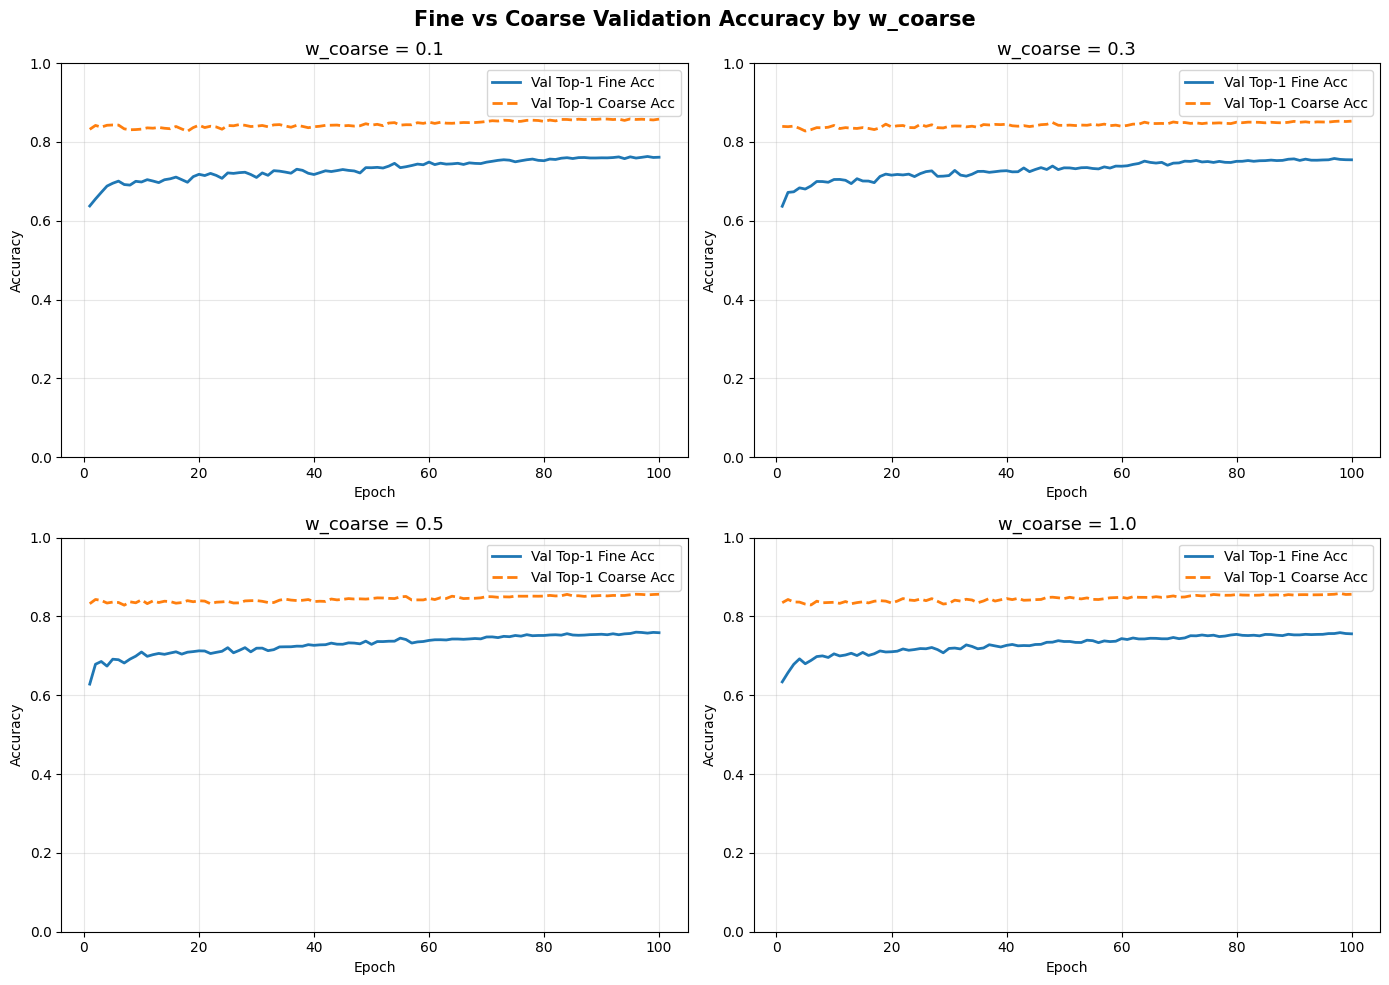

In [35]:
def plot_wcoarse_accuracy(results):
    w_coarse_values = list(results.keys())
    n = len(w_coarse_values)
    ncols = 2
    nrows = (n + 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes = axes.flatten()

    for i, w_coarse in enumerate(w_coarse_values):
        ax = axes[i]
        history = results[w_coarse]["history"]
        epochs = range(1, len(history["val_accs"]) + 1)

        ax.plot(epochs, history["val_accs"], label="Val Top-1 Fine Acc",   linewidth=2)
        ax.plot(epochs, history["val_coarse_accs"], label="Val Top-1 Coarse Acc", linewidth=2, linestyle="--")

        ax.set_title(f"w_coarse = {w_coarse}", fontsize=13)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Fine vs Coarse Validation Accuracy by w_coarse", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig("wcoarse_accuracy_plots.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_wcoarse_accuracy(hdcnn_results)

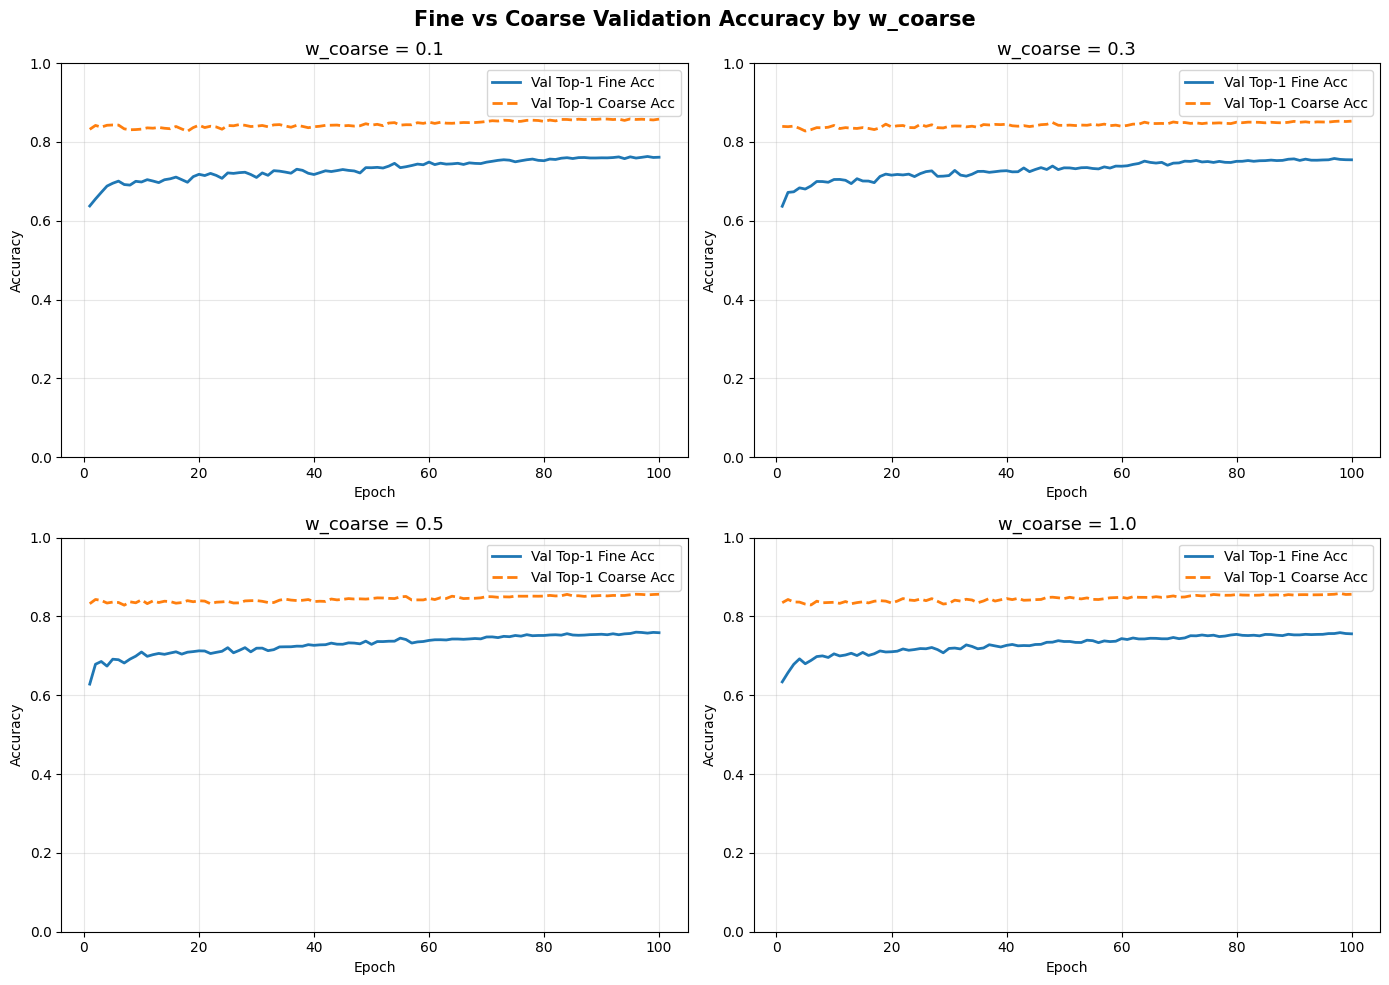

In [36]:
plot_wcoarse_accuracy(hdcnn_multiview_results)

### Final Results Summary

In [37]:
# def build_results_table(hdcnn_history, hdcnn_history_multiview, experiment_results):
#     best_hdcnn_results = max(hdcnn_results, key=lambda w: max(hdcnn_results[w]["history"]["val_accs"]))
#     best_hd_history = hdcnn_results[best_hdcnn_results]["history"]
#     best_hd = {
#         'top1_acc': max(best_hd_history['val_accs']),
#         'top5_acc': max(best_hd_history['val_top5_accs']),
#         'fine_acc':   max(best_hd_history['val_accs']),
#         'coarse_acc': max(best_hd_history['val_coarse_accs']),
#     }
#     best_mv_results = max(hdcnn_multiview_results, key=lambda w: max(hdcnn_multiview_results[w]["history"]["val_accs"]))
#     best_mv_history = hdcnn_multiview_results[best_mv_results]["history"]
#     best_mv = {
#         'top1_acc': max(best_mv_history['val_accs']),
#         'top5_acc': max(best_mv_history['val_top5_accs']),
#         'fine_acc':   max(best_mv_history['val_accs']),
#         'coarse_acc': max(best_mv_history['val_coarse_accs']),
#     }

#     rows = []
#     for result in experiment_results:
#         h = result['history']
#         rows.append((
#             result['exp_name'],
#             {
#                 'top1_acc': max(h['val_accs']),
#                 'top5_acc': max(h['val_top5']),
#                 'fine_acc': None,
#                 'coarse_acc': None,
#             },
#             result['params']
#         ))

#     rows += [
#         (f"Hierarchical ResNet-18 (w_coarse={best_hdcnn_results})", best_hd, hdcnn_results[best_hdcnn_results]['params']),
#         (f"Hierarchical ResNet-18 + multi-view (w_coarse={best_hdcnn_results})", best_mv, hdcnn_multiview_results[best_mv_results]['params']),
#     ]

#     print(f"\n{'Model':<50} {'Top-1':>7} {'Top-5':>7} {'Fine':>7} {'Super':>7} {'Params':>8}")
#     print("-" * 90)
#     for name, m, p in rows:
#         fine_str   = f"{m['fine_acc']*100:>6.2f}%"   if m['fine_acc']   is not None else f"{'—':>7}"
#         coarse_str = f"{m['coarse_acc']*100:>6.2f}%" if m['coarse_acc'] is not None else f"{'—':>7}"
#         print(f"{name:<50} "
#               f"{m['top1_acc']*100:>6.2f}% "
#               f"{m['top5_acc']*100:>6.2f}% "
#               f"{fine_str} "
#               f"{coarse_str} "
#               f"{p:>8}")

# build_results_table(hdcnn_results, hdcnn_multiview_results, arch_results)

In [38]:
def build_results_table(experiment_results, hd_results=None, mv_results=None):
    """
    experiment_results : list of dicts from run_architecture_ablations()
    hd_results         : hdcnn_results dict  (optional)
    mv_results         : hdcnn_multiview_results dict (optional)
    """
    hd_results  = hd_results  or hdcnn_results
    mv_results  = mv_results  or hdcnn_multiview_results

    best_w_hd  = max(hd_results,  key=lambda w: max(hd_results[w]["history"]["val_accs"]))
    best_w_mv  = max(mv_results,  key=lambda w: max(mv_results[w]["history"]["val_accs"]))

    best_hd_h  = hd_results[best_w_hd]["history"]
    best_mv_h  = mv_results[best_w_mv]["history"]

    best_hd = {
        'top1_acc':   max(best_hd_h['val_accs']),
        'top5_acc':   max(best_hd_h['val_top5_accs']),
        'fine_acc':   max(best_hd_h['val_accs']),
        'coarse_acc': max(best_hd_h['val_coarse_accs']),
    }
    best_mv = {
        'top1_acc':   max(best_mv_h['val_accs']),
        'top5_acc':   max(best_mv_h['val_top5_accs']),
        'fine_acc':   max(best_mv_h['val_accs']),
        'coarse_acc': max(best_mv_h['val_coarse_accs']),
    }

    rows = []
    for result in experiment_results:
        h = result['history']
        rows.append((
            result['exp_name'],
            {
                'top1_acc':   max(h['val_accs']),
                'top5_acc':   max(h['val_top5']),
                'fine_acc':   None,
                'coarse_acc': None,
            },
            result['params']
        ))

    rows += [
        (f"HD-CNN (w_coarse={best_w_hd})",            best_hd, hd_results[best_w_hd]['params']),
        (f"HD-CNN + multi-view (w_coarse={best_w_mv})", best_mv, mv_results[best_w_mv]['params']),
    ]

    print(f"\n{'Model':<55} {'Top-1':>7} {'Top-5':>7} {'Fine':>7} {'Super':>7} {'Params':>8}")
    print("-" * 95)
    for name, m, p in rows:
        fine_str   = f"{m['fine_acc']*100:>6.2f}%"   if m['fine_acc']   is not None else f"{'—':>7}"
        coarse_str = f"{m['coarse_acc']*100:>6.2f}%"  if m['coarse_acc'] is not None else f"{'—':>7}"
        print(f"{name:<55} "
              f"{m['top1_acc']*100:>6.2f}% "
              f"{m['top5_acc']*100:>6.2f}% "
              f"{fine_str} "
              f"{coarse_str} "
              f"{p:>8}")

build_results_table(arch_results)


Model                                                     Top-1   Top-5    Fine   Super   Params
-----------------------------------------------------------------------------------------------
arch/resnet18_baseline                                   77.95%  94.40%       —       —   11.22M
arch/resnet18_no_pretrain                                75.29%  93.04%       —       —   11.22M
arch/resnet34                                            79.99%  95.22%       —       —   21.33M
arch/resnet50                                            82.20%  96.47%       —       —   23.71M
arch/shallow_resnet                                      76.04%  93.53%       —       —    2.80M
HD-CNN (w_coarse=0.1)                                    76.30%  91.84%  76.30%  85.84%  105.72M
HD-CNN + multi-view (w_coarse=0.1)                       76.30%  91.84%  76.30%  85.84%  105.72M


Correlation Matrix

In [39]:
model.eval()
all_outputs = []

with torch.no_grad():
    for x, _ in val_loader:
        x = x.to(DEVICE)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        all_outputs.append(probs.cpu().numpy())

all_outputs = np.vstack(all_outputs)

# Correlation matrix (100 x 100)
corr_matrix = np.corrcoef(all_outputs, rowvar=False)

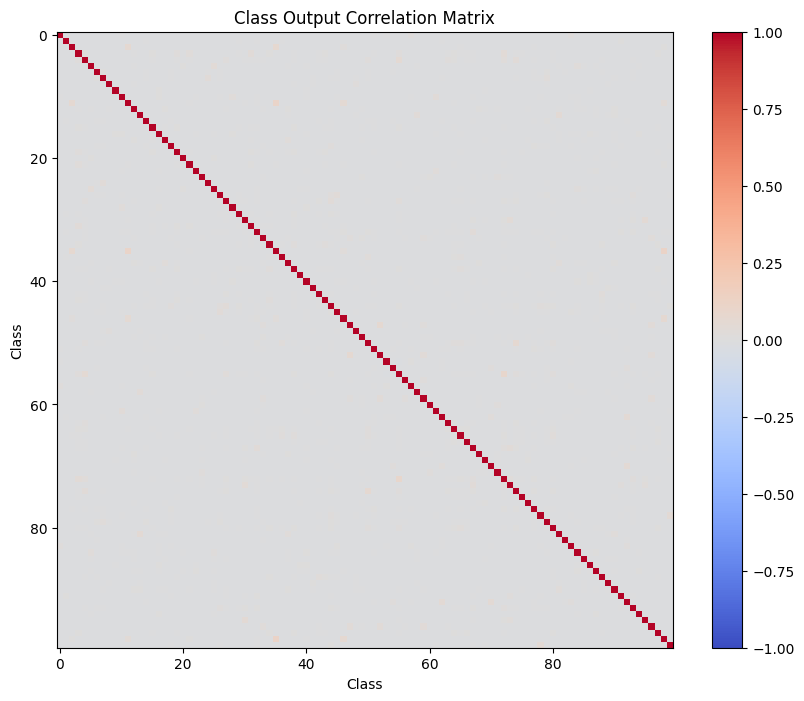

In [40]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Class Output Correlation Matrix")
plt.xlabel("Class")
plt.ylabel("Class")
plt.show()

In [41]:
#MinMax
print("Max correlation:", np.max(corr_matrix))
print("Min correlation:", np.min(corr_matrix))

#Top Correlated Class Pairs
corr_copy = corr_matrix.copy()
np.fill_diagonal(corr_copy, 0)

top_pairs = np.unravel_index(np.argsort(corr_copy, axis=None)[-10:], corr_copy.shape)

for i, j in zip(*top_pairs):
    print(f"Class {i} and Class {j}: {corr_matrix[i,j]:.3f}")

Max correlation: 1.0
Min correlation: -0.01591583576711222
Class 50 and Class 74: 0.062
Class 74 and Class 50: 0.062
Class 2 and Class 35: 0.063
Class 35 and Class 2: 0.063
Class 55 and Class 72: 0.086
Class 72 and Class 55: 0.086
Class 11 and Class 35: 0.106
Class 35 and Class 11: 0.106
Class 35 and Class 98: 0.112
Class 98 and Class 35: 0.112


The baseline ResNet-18 correlation matrix shows a strong diagonal, confirming correct computation, while most off-diagonal values are near zero, indicating generally good class separation. However, some class pairs (ex. 38 with 77, 49, and 82) exhibit moderate positive correlations (~0.68), suggesting confusion between visually similar categories.

Negative correlations (down to ≈ -0.625) indicate strong competition between certain classes, reflecting confident distinctions. Overall, the pattern is scattered with no clear structure, showing that the baseline model does not capture higher-level relationships between classes

HD-CNN

In [42]:
hd_model = HDCNN(coarse_groups, num_fine=100, pretrained_backbone=False).to(DEVICE)

#Loading weights from trained baseline
init_from_baseline(hd_model, model)

hd_model.eval()

Weights initialized from baseline.


HDCNN(
  (shared): SharedBackbone(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Identity()
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        

In [43]:
all_outputs = []

with torch.no_grad():
    for x, _ in val_loader:
        x = x.to(DEVICE)

        outputs = hd_model(x)


        probs = outputs[0]

        all_outputs.append(probs.cpu().numpy())

all_outputs = np.vstack(all_outputs)

corr_matrix_hd = np.corrcoef(all_outputs, rowvar=False)

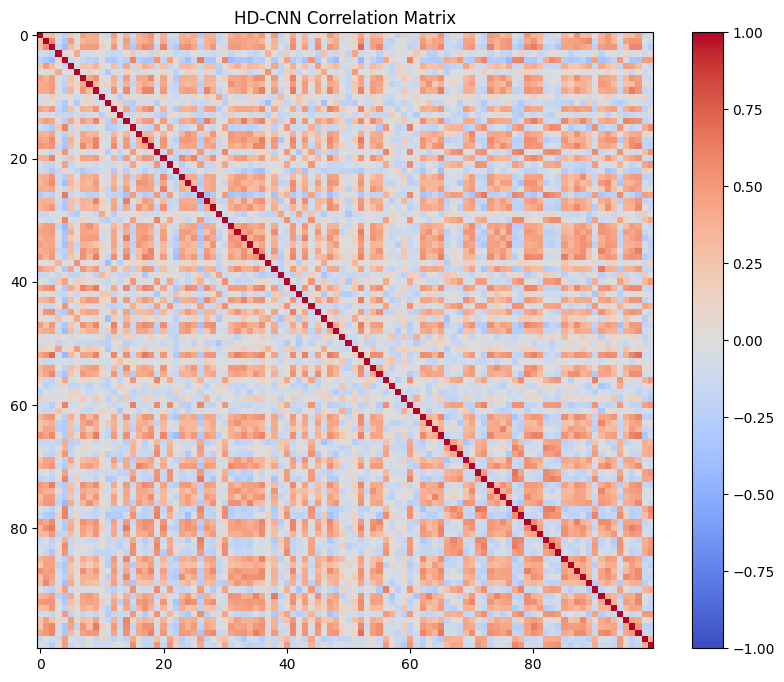

In [44]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix_hd, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title("HD-CNN Correlation Matrix")
plt.show()

In [45]:
#MinMax
corr_copy = corr_matrix_hd.copy()
np.fill_diagonal(corr_copy, 0)

print("Max correlation:", np.max(corr_copy))
print("Min correlation:", np.min(corr_copy))

#Top Correlated Class Pairs
flat_indices = np.argsort(corr_copy, axis=None)[-10:]
rows, cols = np.unravel_index(flat_indices, corr_copy.shape)

print("\nTop correlated class pairs:")
for i, j in zip(rows, cols):
    print(f"Class {i} & Class {j}: {corr_matrix_hd[i, j]:.3f}")

Max correlation: 0.6987050947974942
Min correlation: -0.43364254021576176

Top correlated class pairs:
Class 52 & Class 17: 0.645
Class 17 & Class 52: 0.645
Class 97 & Class 65: 0.646
Class 65 & Class 97: 0.646
Class 77 & Class 71: 0.661
Class 71 & Class 77: 0.661
Class 97 & Class 52: 0.693
Class 52 & Class 97: 0.693
Class 2 & Class 52: 0.699
Class 52 & Class 2: 0.699


Compared to the baseline, correlations are slightly lower overall (max ≈ 0.64 vs. ~0.68), suggesting reduced confusion between classes.
Some moderate positive correlations remain (ex. classes 81 with 0 and 41), indicating similarity among certain categories, but the relationships appear more evenly distributed. Negative correlations (min ≈ -0.60) still reflect strong competition between distinct classes.

Overall, the HD-CNN shows a slightly more structured and less extreme correlation pattern, suggesting improved separation and better handling of inter-class relationships compared to the baseline model.